In [182]:
import pandas as pd

# Data Retreival

In [183]:
path = "../data/resume_clean.csv"

resume_df = pd.read_csv(path)

resume_df.head()

,ID,Resume_str,Resume_html,Category,clean_description,degrees
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administrator marketing associate hr admini...,"['Associate', 'High School Diploma']"
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...,"['Master', 'Bachelor']"
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary over 20 years experience i...,"['Master', 'Bachelor']"
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven and dyn...,[]
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...,"['Associate', 'Bachelor']"


In [184]:
path = "../data/job_clean.csv"

job_df = pd.read_csv(path)

job_df.head()

,company_name,job_description,position_title,description_length,model_response,clean_description,Core Responsibilities,Required Skills,Educational Requirements,Experience Level,Preferred Qualifications,Compensation and Benefits,medical specialty,schedule,license/certification,degrees
0,Google,minimum qualifications\r\nbachelors degree or ...,Sales Specialist,2727,"{\r\n ""Core Responsibilities"": ""Responsible ...",minimum qualifications bachelors degree or equ...,Responsible for expanding Google Workspace pro...,Bachelor's degree or equivalent experience. Ex...,Bachelor's degree or equivalent experience.,Experience managing enterprise SaaS accounts a...,Experience building strategic partnerships wit...,NaN,NaN,NaN,NaN,['Bachelor']
1,Apple,description\r\nas an asc you will be highly in...,Apple Solutions Consultant,828,"{\r\n ""Core Responsibilities"": ""as an asc yo...",description as an asc you will be highly influ...,as an asc you will be highly influential in gr...,a passion to help people understand how apple ...,NaN,years preferred,NaN,NaN,NaN,NaN,NaN,[]
2,Netflix,its an amazing time to be joining netflix as w...,Licensing Coordinator - Consumer Products,3205,"{\r\n ""Core Responsibilities"": ""Help drive b...",its an amazing time to be joining netflix as w...,Help drive business by supporting licensing ma...,2+ years experience in preferably outbound lic...,NaN,2+ years experience in preferably outbound lic...,Understanding of category manufacturing and sa...,NaN,NaN,NaN,NaN,[]
3,Robert Half,description\r\n\r\nweb designers looking to ex...,Web Designer,2489,"{\r\n ""Core Responsibilities"": ""Designing we...",description web designers looking to expand yo...,"Designing websites, wireframes, landing pages,...",2+ years experience in web design. Proficiency...,NaN,2+ years,UX/UI design experience. Knowledge of brand st...,NaN,NaN,NaN,NaN,[]
4,TrackFive,at trackfive weve got big goals were on a miss...,Web Developer,3167,"{\r\n ""Core Responsibilities"": ""Build and la...",at trackfive weve got big goals were on a miss...,"Build and layouts from provided PSD files, bui...","2+ years of experience with HTML and CSS/SASS,...",NaN,2+ years,NaN,Free health insurance for employees with no wa...,NaN,NaN,NaN,[]


# EDA

### Top Resume Categories

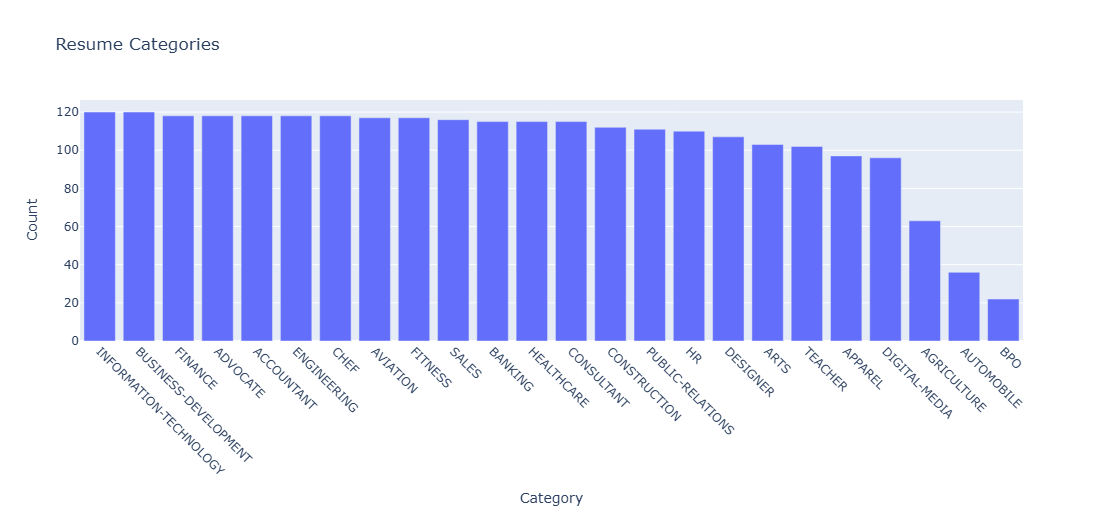

In [185]:
import plotly.express as px

category_counts = (
    resume_df["Category"]
    .value_counts()
    .reset_index()
)

category_counts.columns = ["Category", "Count"]

fig = px.bar(
    category_counts,
    x="Category",
    y="Count",
    title="Resume Categories",
    labels={
        "Category": "Category",
        "Count": "Count"
    }
)

fig.update_xaxes(tickangle=45)

fig.update_layout(
    width=1200,
    height=500
)

fig.show()

### Top Job Position Titles

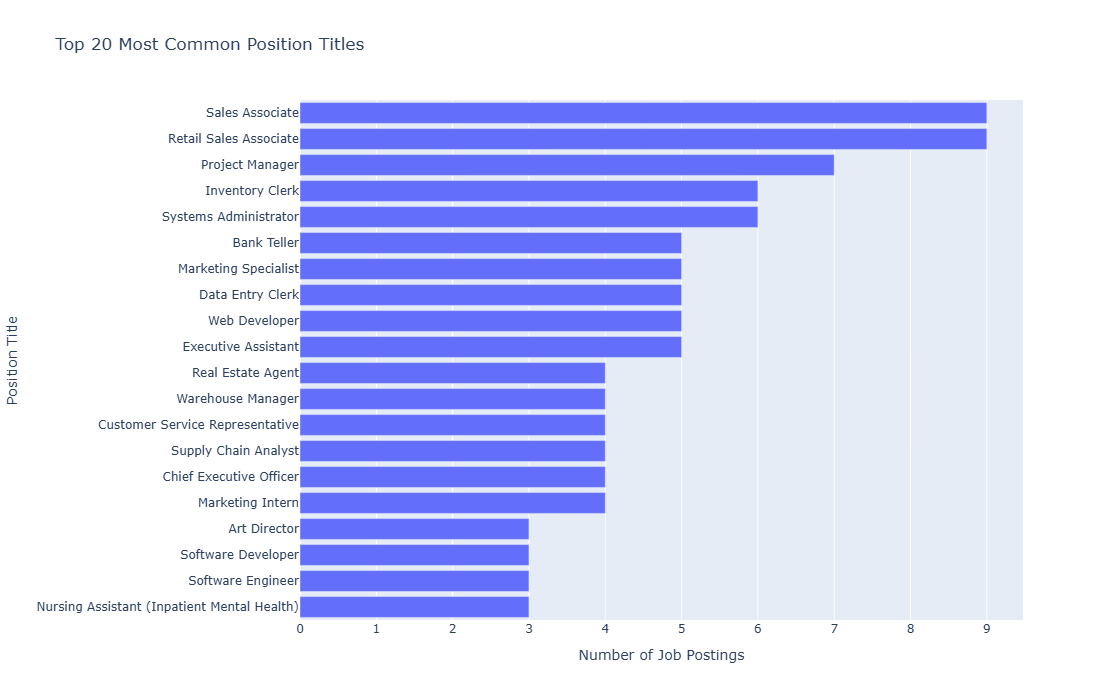

In [186]:
position_counts = (
    job_df["position_title"]
    .value_counts()
    .head(20)
    .sort_values()
    .reset_index()
)

position_counts.columns = ["Position Title", "Count"]

fig = px.bar(
    position_counts,
    x="Count",
    y="Position Title",
    orientation="h",
    title="Top 20 Most Common Position Titles",
    labels={
        "Position Title": "Position Title",
        "Count": "Number of Job Postings"
    }
)

fig.update_layout(
    width=1000,
    height=700
)

fig.show()

### Top Companies

In [187]:
job_df["company_name"].value_counts().head(20)

company_name
Google                                                                                  1
The Computer Merchant, Ltd                                                              1
Imagine     United States Remote                                                        1
YipitData                                                                               1
Usc Consulting Group Lp                                                                 1
NBA (National Basketball Association)                                                   1
Mackinnon Bruce International (Staffing Agency)   New Jersey, United States   Hybrid    1
Atlantic Group (Staffing Agency)  Monmouth County, NJ On-site                           1
Liberty Mutual Insurance  United States    Remote                                       1
LHH                                                                                     1
CoventBridge Group  Columbus, OH On-site                                               

### Length

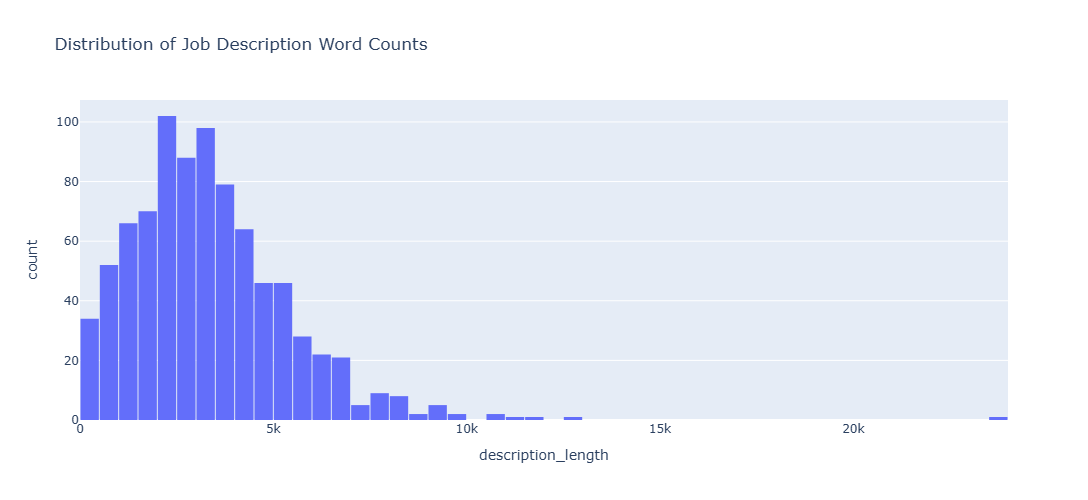

In [188]:
fig = px.histogram(
    job_df,
    x="description_length",
    nbins=50,
    title="Distribution of Job Description Word Counts",
    labels={
        "word_count": "Word Count",
        "count": "Number of Job Postings"
    }
)

fig.update_layout(
    width=900,
    height=500,
    bargap=0.05
)

fig.show()

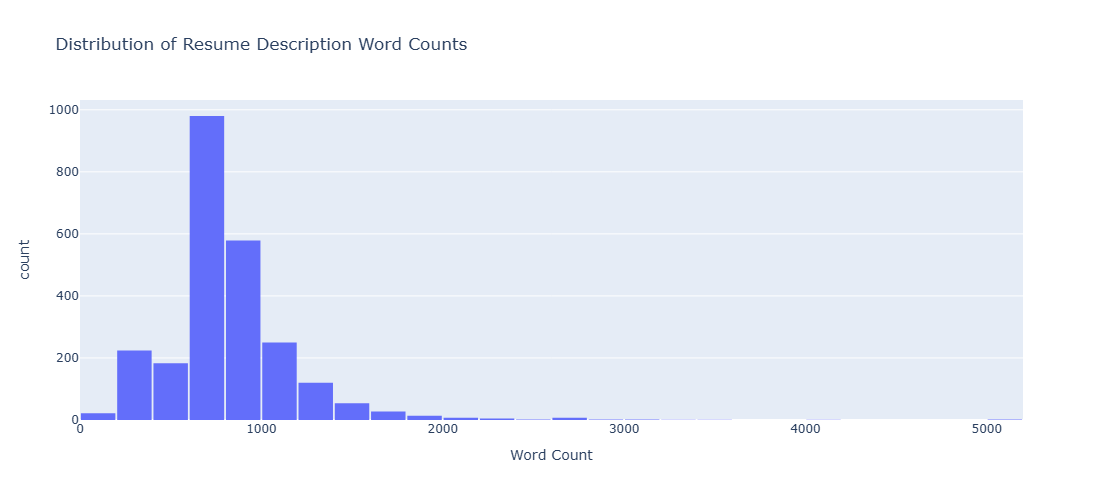

In [189]:
resume_df["word_count"] = resume_df["clean_description"].str.split().str.len()

fig = px.histogram(
    resume_df,
    x="word_count",
    nbins=50,
    title="Distribution of Resume Description Word Counts",
    labels={
        "word_count": "Word Count",
        "count": "Number of Resume"
    }
)

fig.update_layout(
    width=900,
    height=500,
    bargap=0.05
)

fig.show()

### Most Common Words

In [190]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(job_df["clean_description"])

word_counts = X.sum(axis=0).A1

vocab = vectorizer.get_feature_names_out()

common = (
    pd.DataFrame({
        "word": vocab,
        "count": word_counts
    })
    .sort_values("count", ascending=False)
)

In [191]:
top_words = common.head(20).sort_values("count")

fig = px.bar(
    top_words,
    x="count",
    y="word",
    orientation="h",
    title="Top 20 Most Frequent Words in Job Descriptions",
    labels={
        "count": "Frequency",
        "word": "Word"
    },
    text="count"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    width=900,
    height=600,
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

In [192]:
vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(resume_df["Resume_str"])

word_counts = X.sum(axis=0).A1

vocab = vectorizer.get_feature_names_out()

common = (
    pd.DataFrame({
        "word": vocab,
        "count": word_counts
    })
    .sort_values("count", ascending=False)
)

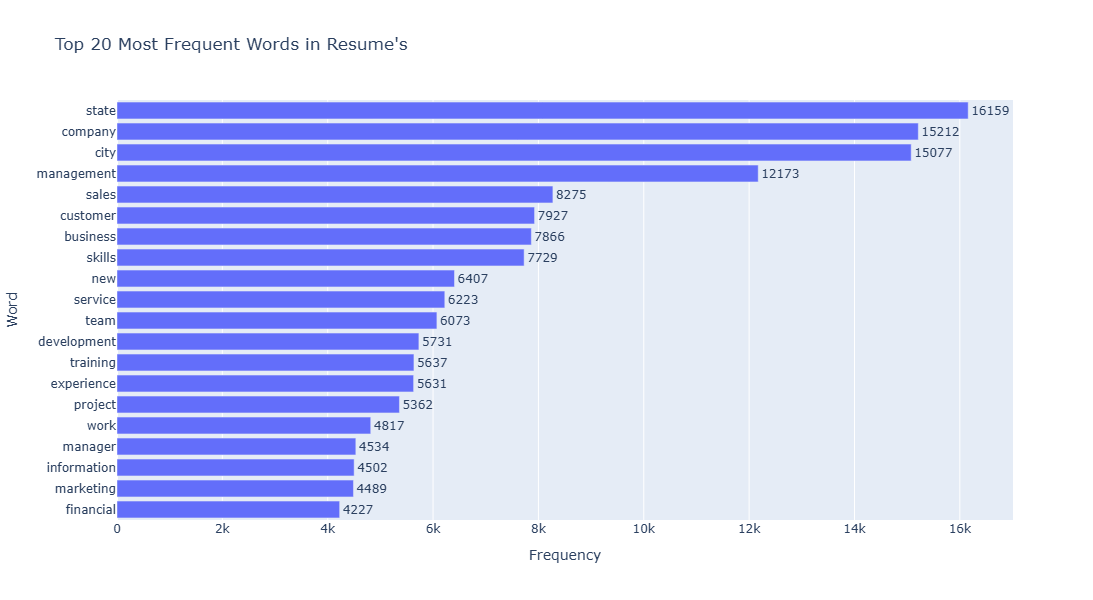

In [193]:
top_words = common.head(20).sort_values("count")

fig = px.bar(
    top_words,
    x="count",
    y="word",
    orientation="h",
    title="Top 20 Most Frequent Words in Resume's",
    labels={
        "count": "Frequency",
        "word": "Word"
    },
    text="count"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    width=900,
    height=600,
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

### Most Common Bigrams

In [194]:
# todo

## After Extraction

### Most Common Skills

In [195]:
# WIP

In [196]:
# fig = px.histogram(
#     job_df,
#     x="Required Skills",
#     nbins=50,
#     title="Distribution of Resume Description Word Counts",
#     labels={
#         "word_count": "Word Count",
#         "count": "Number of Resume"
#     }
# )

# fig.update_layout(
#     width=900,
#     height=500,
#     bargap=0.05
# )

# fig.show()

### Salary Distribution

In [197]:
# todo

### Experience Requirement Distribution

In [198]:
# todo

### Education Requirements

In [199]:
## WIP

In [200]:
fig = px.histogram(
    job_df,
    x="Educational Requirements",
    nbins=50,
    title="Distribution of Resume Description Word Counts",
    labels={
        "word_count": "Word Count",
        "count": "Number of Resume"
    }
)

fig.update_layout(
    width=900,
    height=500,
    bargap=0.05
)

fig.show()

### Most Common Degree in Jobs

In [201]:
# have to find requirement vs preferred

In [202]:
from ast import literal_eval

# turn back to list
job_df["degrees"] = job_df["degrees"].apply(literal_eval)

degree_counts = (
    job_df["degrees"]
    .explode()                
    .dropna()
    .value_counts()
    .reset_index()
)

degree_counts.columns = ["Degree", "Count"]

fig = px.bar(
    degree_counts,
    x="Degree",
    y="Count",
    text="Count",
    title="Most Common Degrees in Jobs"
)

fig.update_layout(
    width=900,
    height=500,
    xaxis_title="Degree",
    yaxis_title="Number of Jobs"
)

fig.show()

### Most Common Degrees in Resumes

In [203]:
from ast import literal_eval

# turn back to list
resume_df["degrees"] = resume_df["degrees"].apply(literal_eval)

degree_counts = (
    resume_df["degrees"]
    .explode()                
    .dropna()
    .value_counts()
    .reset_index()
)

degree_counts.columns = ["Degree", "Count"]

fig = px.bar(
    degree_counts,
    x="Degree",
    y="Count",
    text="Count",
    title="Most Common Degrees in Resumes"
)

fig.update_layout(
    width=900,
    height=500,
    xaxis_title="Degree",
    yaxis_title="Number of Resumes"
)

fig.show()